In [4]:
from pointnet2_ops import pointnet2_modules

dir(pointnet2_modules)

['F',
 'List',
 'Optional',
 'PointnetFPModule',
 'PointnetSAModule',
 'PointnetSAModuleMSG',
 'Tuple',
 '_PointnetSAModuleBase',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'build_shared_mlp',
 'nn',
 'pointnet2_utils',
 'torch']

In [1]:
import torch; print(torch.__version__, torch.version.cuda)

2.5.1+cu124 12.4


In [2]:
import numpy as np
import plotly.graph_objects as go

# Pfad zur NPY-Datei
npy_file = "/home/tepper/generative-point-cloud-completion/Point_Diffusion_Refinement/pointnet2/results/pdr_evaluation/samples/sample_0002_label0/rfnet.npy"

# Punktwolke laden
points = np.load(npy_file)

print("Shape:", points.shape)

# Falls Shape (1, N, 3)
if len(points.shape) == 3 and points.shape[0] == 1:
    points = points[0]

# Prüfung
if points.shape[1] != 3:
    raise ValueError(
        f"Erwartet Shape (N,3), erhalten: {points.shape}"
    )

# Plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(
                size=2,
                opacity=0.8
            )
        )
    ]
)

fig.update_layout(
    title="Point Cloud",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

Shape: (5000, 3)


In [3]:
import numpy as np
import h5py
import open3d as o3d

# RFNet laden
with h5py.File('realpc_dataloader/data/realpc_dataset/generated_samples/T1000_betaT0.02_realpc_completion_5000/refine_exp_ckpt_94149_standard_attention_10_trials/pointnet_ckpt_24209_best_cd/test/realpc_generated_data_5000pts.h5') as f:
    rfnet_data = np.array(f['data'])

# GT aus dem Dataloader laden (gleiche Reihenfolge)
from mvp_dataloader.realpc_dataset import RealPCDataset
ds = RealPCDataset(
    data_dir='/home/tepper/generative-point-cloud-completion/realpc/difficult',
    train=False, n_partial=2048, n_complete=5000,
    num_scans_per_object=26, scale=1.0)

# Sample 0 vergleichen
sample = ds[0]
gt = sample['complete'].numpy() / 2  # gleiche Skalierung wie generate_samples.py
rfnet = rfnet_data[0]

print(f"GT range: [{gt.min():.4f}, {gt.max():.4f}]")
print(f"RFNet range: [{rfnet.min():.4f}, {rfnet.max():.4f}]")

# Chamfer Distance manuell prüfen
import torch
gt_t = torch.from_numpy(gt).float()
rf_t = torch.from_numpy(rfnet).float()
diff = gt_t.unsqueeze(0) - rf_t.unsqueeze(1)
dist = torch.norm(diff, dim=-1)
cd = 0.5 * (dist.min(dim=1)[0].mean() + dist.min(dim=0)[0].mean())
print(f"CD-L1 Sample 0: {cd.item():.6f}")

# Als PLY speichern
pcd_gt = o3d.geometry.PointCloud()
pcd_gt.points = o3d.utility.Vector3dVector(gt)
o3d.io.write_point_cloud("./gt_sample0.ply", pcd_gt)

pcd_rf = o3d.geometry.PointCloud()
pcd_rf.points = o3d.utility.Vector3dVector(rfnet)
o3d.io.write_point_cloud("./rfnet_sample0.ply", pcd_rf)

print("Saved to ./gt_sample0.ply and ./rfnet_sample0.ply")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
RealPC [test]: 193 objects, 5018 samples, partial=2048pts, complete=5000pts
GT range: [-0.4766, 0.4993]
RFNet range: [-0.5293, 0.5436]
CD-L1 Sample 0: 0.005898
Saved to ./gt_sample0.ply and ./rfnet_sample0.ply


In [ ]:
import open3d as o3d
gt = o3d.io.read_point_cloud('./gt_sample0.ply')
rf = o3d.io.read_point_cloud('./rfnet_sample0.ply')
gt.paint_uniform_color([0, 0, 1])
rf.paint_uniform_color([1, 0, 0])

vis = o3d.visualization.Visualizer()
vis.create_window(visible=False)
vis.add_geometry(gt)
vis.add_geometry(rf)
vis.poll_events()
vis.update_renderer()
vis.capture_screen_image('./comparison_sample0.png')
vis.destroy_window()
print("Saved to ./comparison_sample0.png")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
RealPC [test]: 193 objects, 5018 samples, partial=2048pts, complete=5000pts


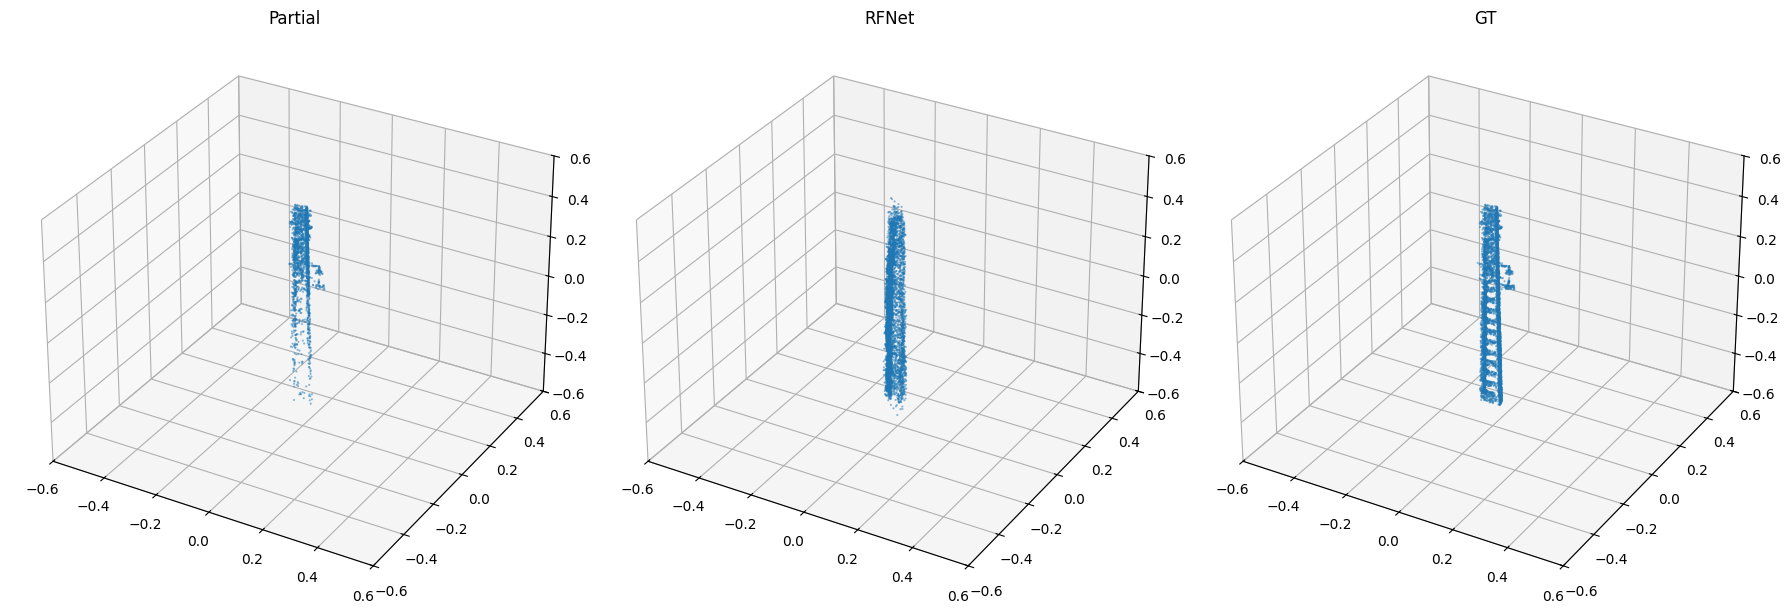

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Laden
with h5py.File('realpc_dataloader/data/realpc_dataset/generated_samples/T1000_betaT0.02_realpc_completion_5000/refine_exp_ckpt_94149_standard_attention_10_trials/pointnet_ckpt_24209_best_cd/test/realpc_generated_data_5000pts.h5') as f:
    rfnet_data = np.array(f['data'])

from mvp_dataloader.realpc_dataset import RealPCDataset
ds = RealPCDataset(
    data_dir='/home/tepper/generative-point-cloud-completion/realpc/difficult',
    train=False, n_partial=2048, n_complete=5000,
    num_scans_per_object=26, scale=1.0)

sample = ds[0]
gt = sample['complete'].numpy() / 2
partial = sample['partial'].numpy() / 2
rfnet = rfnet_data[0]

# 3 Plots nebeneinander
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})

for ax, pts, title in zip(axes, [partial, rfnet, gt], ['Partial', 'RFNet', 'GT']):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3, alpha=0.5)
    ax.set_title(title)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    ax.set_zlim(-0.6, 0.6)

plt.tight_layout()
plt.savefig('/tmp/comparison.png', dpi=150)
plt.show()

RealPC [test]: 193 objects, 5018 samples, partial=2048pts, complete=5000pts
CGNet vs RFNet max diff: 0.172629
CGNet vs RFNet mean diff: 0.038115
CGNet == RFNet? False


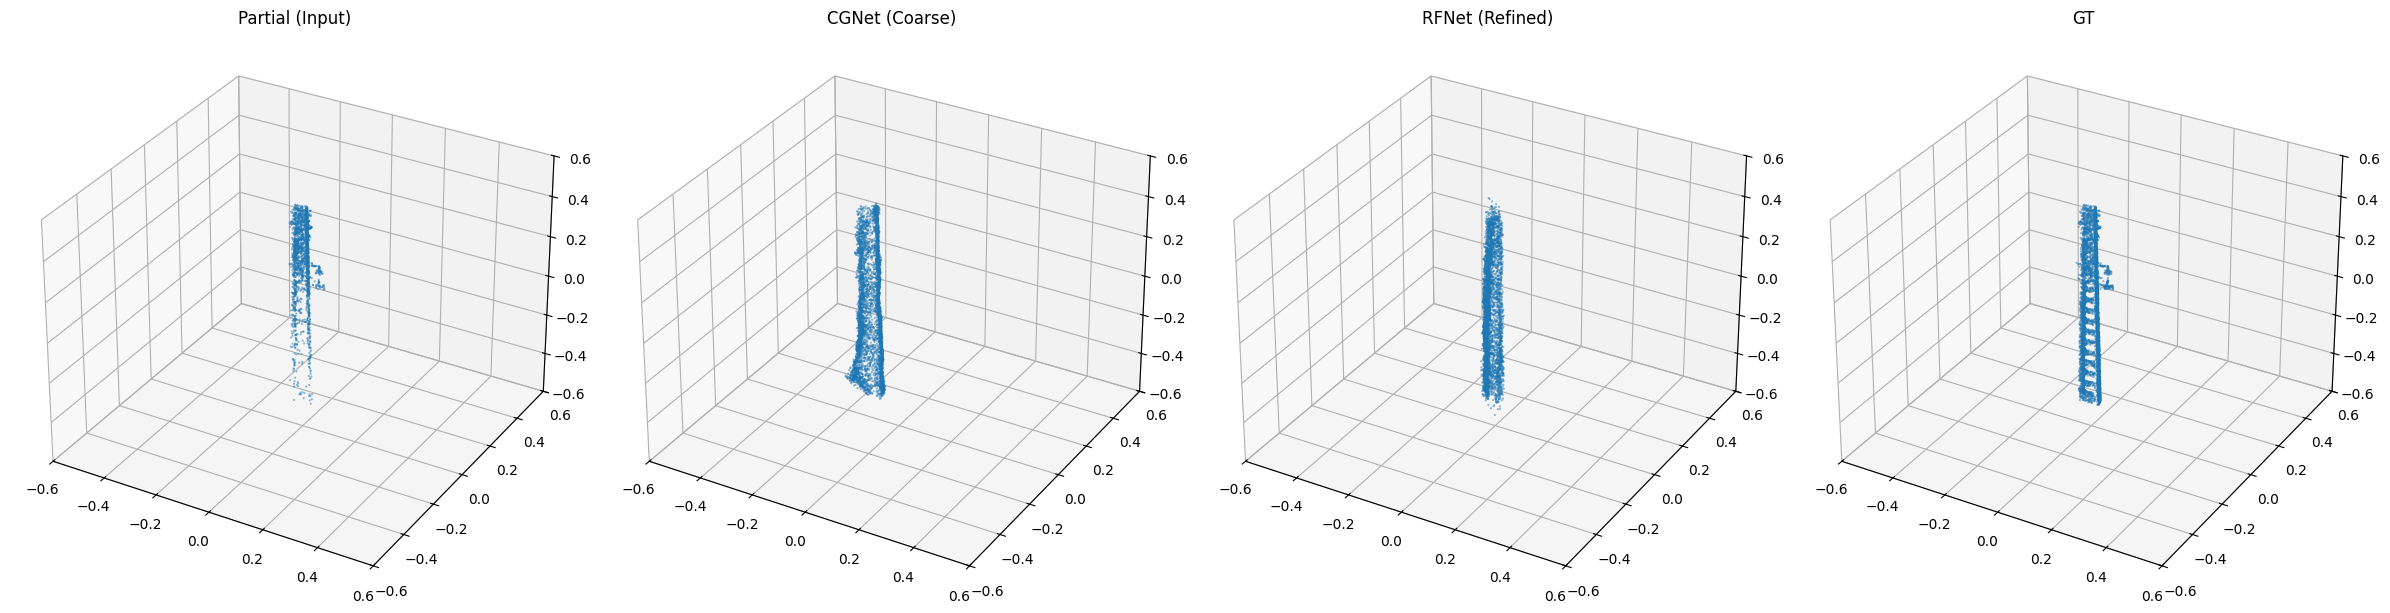

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# CGNet, RFNet und GT laden
with h5py.File('realpc_dataloader/data/realpc_dataset/generated_samples/T1000_betaT0.02_realpc_completion_5000/pointnet_ckpt_94149/test/realpc_generated_data_5000pts.h5') as f:
    cgnet_data = np.array(f['data'])

with h5py.File('realpc_dataloader/data/realpc_dataset/generated_samples/T1000_betaT0.02_realpc_completion_5000/refine_exp_ckpt_94149_standard_attention_10_trials/pointnet_ckpt_24209_best_cd/test/realpc_generated_data_5000pts.h5') as f:
    rfnet_data = np.array(f['data'])

from mvp_dataloader.realpc_dataset import RealPCDataset
ds = RealPCDataset(
    data_dir='/home/tepper/generative-point-cloud-completion/realpc/difficult',
    train=False, n_partial=2048, n_complete=5000,
    num_scans_per_object=26, scale=1.0)

# Sample 0
sample = ds[0]
gt = sample['complete'].numpy() / 2
partial = sample['partial'].numpy() / 2
cgnet = cgnet_data[0]
rfnet = rfnet_data[0]

# Differenz prüfen
print(f"CGNet vs RFNet max diff: {np.abs(cgnet - rfnet).max():.6f}")
print(f"CGNet vs RFNet mean diff: {np.abs(cgnet - rfnet).mean():.6f}")
print(f"CGNet == RFNet? {np.allclose(cgnet, rfnet, atol=0.01)}")

# 4 Plots
fig, axes = plt.subplots(1, 4, figsize=(24, 6), subplot_kw={'projection': '3d'})
for ax, pts, title in zip(axes, [partial, cgnet, rfnet, gt],
                           ['Partial (Input)', 'CGNet (Coarse)', 'RFNet (Refined)', 'GT']):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3, alpha=0.5)
    ax.set_title(title)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    ax.set_zlim(-0.6, 0.6)
plt.tight_layout()
plt.savefig('/tmp/full_comparison.png', dpi=150)
plt.show()

In [3]:
for idx in [0, 100, 500, 1000, 3000]:
    sample = ds[idx]
    gt = sample['complete'].numpy() / 2
    rfnet = rfnet_data[idx]

    import torch
    gt_t = torch.from_numpy(gt).float()
    rf_t = torch.from_numpy(rfnet).float()
    diff = gt_t.unsqueeze(0) - rf_t.unsqueeze(1)
    dist = torch.norm(diff, dim=-1)
    cd = 0.5 * (dist.min(dim=1)[0].mean() + dist.min(dim=0)[0].mean())
    print(f"Sample {idx}: CD-L1={cd.item():.6f}, label={sample['label']}")

Sample 0: CD-L1=0.005898, label=0
Sample 100: CD-L1=0.005746, label=0
Sample 500: CD-L1=0.006648, label=0
Sample 1000: CD-L1=0.005740, label=0
Sample 3000: CD-L1=0.010881, label=4


In [4]:
import numpy as np
import pickle
import h5py
from collections import defaultdict

REALPC_CATEGORIES = [
    'chine_0', 'chine_1', 'chine_2', 'chine_3',
    'dutch_0', 'dutch_1', 'dutch_2', 'dutch_3', 'dutch_4',
    'hung_0', 'hung_1', 'hung_2', 'hung_3', 'hung_4', 'hung_5', 'hung_6', 'hung_7',
    'sncf_0', 'sncf_1', 'sncf_2', 'sncf_3',
]

# Eval-Ergebnisse laden
eval_path = 'realpc_dataloader/data/realpc_dataset/generated_samples/T1000_betaT0.02_realpc_completion_5000/refine_exp_ckpt_94149_standard_attention_10_trials/pointnet_ckpt_24209_best_cd/test/eval_result_pointnet_ckpt_24209_best_cd.pkl'
with open(eval_path, 'rb') as f:
    results = pickle.load(f)

labels = results['meta']
cd = results['cd_distance']
f1 = results['f1']

# Per-Category
cat_results = defaultdict(lambda: {'cd': [], 'f1': [], 'count': 0})
for i in range(len(labels)):
    cat = REALPC_CATEGORIES[int(labels[i])]
    cat_results[cat]['cd'].append(cd[i])
    cat_results[cat]['f1'].append(f1[i])
    cat_results[cat]['count'] += 1

# Per-Superclass
super_results = defaultdict(lambda: {'cd': [], 'f1': []})
for cat, r in cat_results.items():
    sc = cat.split('_')[0]
    super_results[sc]['cd'].extend(r['cd'])
    super_results[sc]['f1'].extend(r['f1'])

# Ausgabe
print(f"{'Category':<12} {'Count':>6} {'CD (×10³)':>12} {'F1':>8}")
print("=" * 42)
for cat in REALPC_CATEGORIES:
    if cat in cat_results:
        r = cat_results[cat]
        print(f"{cat:<12} {r['count']:>6} {np.mean(r['cd'])*1000:>12.4f} {np.mean(r['f1']):>8.4f}")

print("\n" + "=" * 42)
print(f"{'Superclass':<12} {'Count':>6} {'CD (×10³)':>12} {'F1':>8}")
print("=" * 42)
for sc in ['chine', 'dutch', 'hung', 'sncf']:
    r = super_results[sc]
    print(f"{sc:<12} {len(r['cd']):>6} {np.mean(r['cd'])*1000:>12.4f} {np.mean(r['f1']):>8.4f}")

print("\n" + "=" * 42)
print(f"{'MEAN':<12} {len(cd):>6} {np.mean(cd)*1000:>12.4f} {np.mean(f1):>8.4f}")

Category      Count    CD (×10³)       F1
chine_0        2184       0.1824   0.8817
chine_1         312       0.3065   0.7013
chine_2         312       0.4285   0.5539
chine_3          78       0.3979   0.6452
dutch_0         390       1.0744   0.4885
dutch_1         286       1.6910   0.4368
dutch_2          52       0.5942   0.7732
dutch_3         156       1.0696   0.5786
dutch_4          52      17.0791   0.1296
hung_0           26       5.5814   0.0125
hung_1           26       0.8763   0.4857
hung_2          130       1.6616   0.5011
hung_3          312       2.5827   0.3779
hung_4          104       0.7467   0.5325
hung_5           26       0.9241   0.2856
hung_6           52       1.1084   0.5655
hung_7           52       4.2623   0.3324
sncf_0          156       0.1386   0.8324
sncf_1           52       0.4526   0.8180
sncf_2          234       0.1660   0.8625
sncf_3           26       0.2833   0.6574

Superclass    Count    CD (×10³)       F1
chine          2886       0.2283 